In [259]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [260]:
def load_dataset(filename):
    df = pd.read_csv(filename)
    # Get the number of points as the largest multiple of 30
    num_points_to_read = df.shape[0] // 30 * 30
    df = df.iloc[:num_points_to_read]

    # Change the first column "id" into "angle" in degrees, assuming the number of points to read will always be 360
    df.iloc[:, 0] = np.arange(num_points_to_read) * 360 / num_points_to_read

    # Rename the first column to "angle"
    df.rename(columns={df.columns[0]: "angle"}, inplace=True)

    # For each column, if the column name is not "angle", write as a difference from the mean of that column and round to 2 decimal places
    for col in df.columns:
        if col != "angle":
            df[col] = df[col] - df[col].mean()
            df[col] = df[col].round(2)

    # add a new column called "total" that is the sum of that row's values for all columns except "angle"
    df["total"] = df.drop(columns=["angle"]).sum(axis=1)

    # I want to return thed dataframe and the sample frequency, which is the number of points divided by 360
    sample_frequency = num_points_to_read / 360
    
    return df, sample_frequency

def plot_graph(df, x_col, y_col, title=None, xlabel=None, ylabel=None):
    plt.figure(figsize=(10, 6))
    plt.plot(df[x_col], df[y_col], marker='o', linestyle='-')
    if title:
        plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    plt.grid()
    plt.show()


In [261]:
# Read all the phatoms
phantoms = {
    "a_known": [load_dataset(f"data/expt_8_sample_a.csv"), load_dataset(f"data/expt_8_sample_a_redo.csv")],
    "b_known": [load_dataset(f"data/expt_8_sample_b.csv"), load_dataset(f"data/expt_8_sample_b_redo.csv")],
    "c_known": [load_dataset(f"data/expt_8_sample_c.csv"), load_dataset(f"data/expt_8_sample_c_redo.csv")],

    "d_unknown": [load_dataset(f"data/expt_8_sample_d.csv"), load_dataset(f"data/expt_8_sample_d_redo.csv")],
    "f_unknown": [load_dataset(f"data/expt_8_sample_f.csv"), load_dataset(f"data/expt_8_sample_f_redo.csv")],

    "nerve_in_ecoflex_known": [load_dataset(f"data/expt_8_nerve_sample.csv"), load_dataset(f"data/expt_8_nerve_sample_redo.csv")],

    "non_nerve_tissue_known": [load_dataset(f"data/expt_8_tissue_sample_1.csv"), load_dataset(f"data/expt_8_retry_tissue_sample_1.csv"),
                        load_dataset(f"data/expt_8_final_tissue_sample_1.csv")],

    "nerve_on_tissue_known": [load_dataset(f"data/expt_8_tissue_sample_2.csv"), load_dataset(f"data/expt_8_retry_tissue_sample_2.csv"),
                              load_dataset(f"data/expt_8_final_tissue_sample_2.csv")],

    "air_known": [load_dataset(f"data/air.csv")],
    "nerve_in_air_known": [load_dataset(f"data/nerve_in_air.csv"), load_dataset(f"data/nerve_in_air_2.csv")],
    "cellophane_known": [load_dataset(f"data/cellophane.csv")],

}

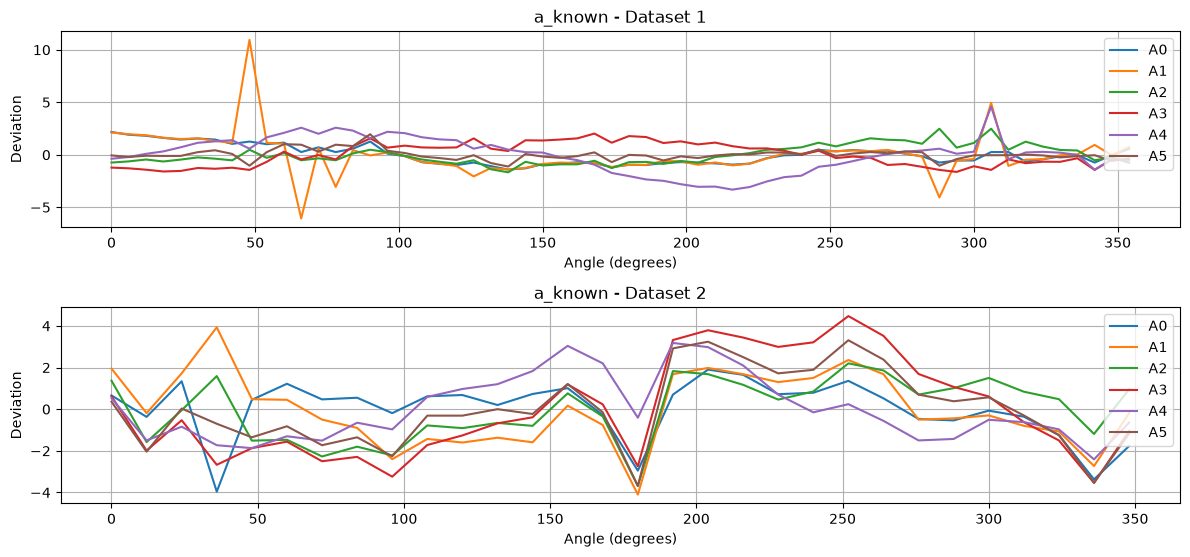

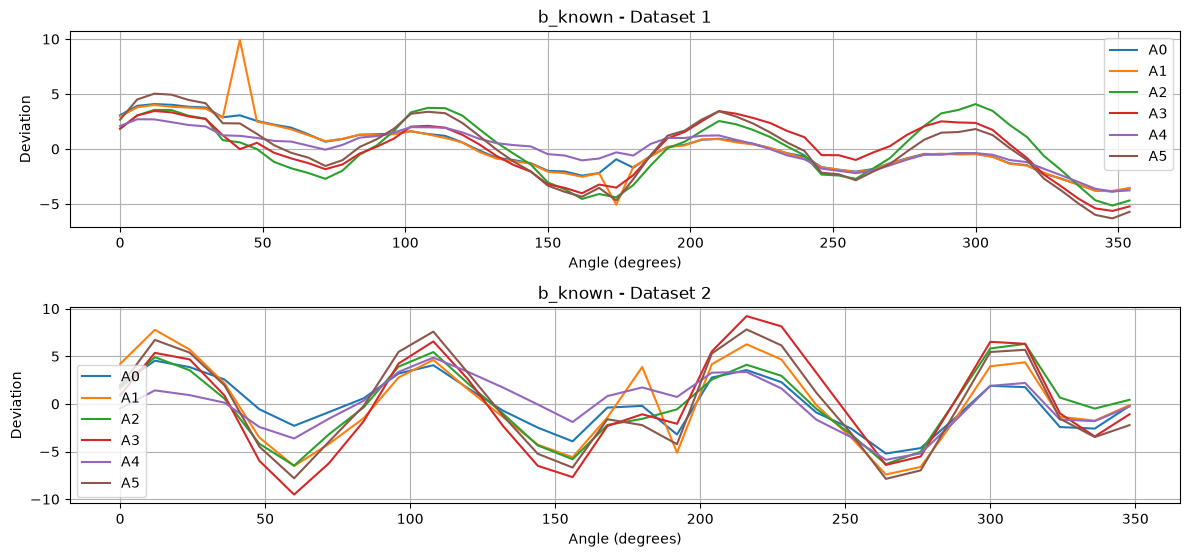

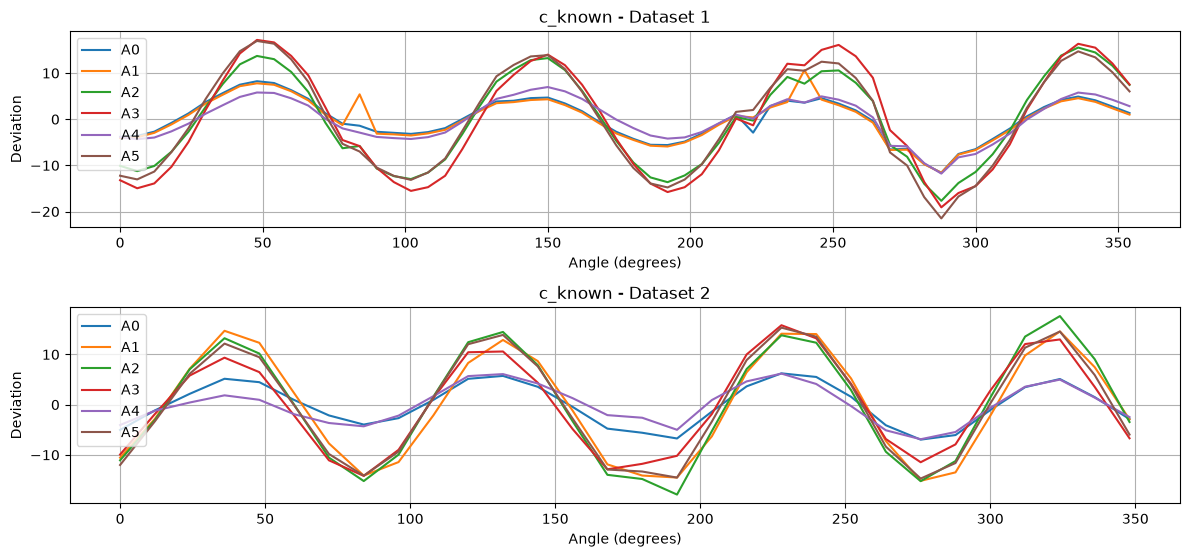

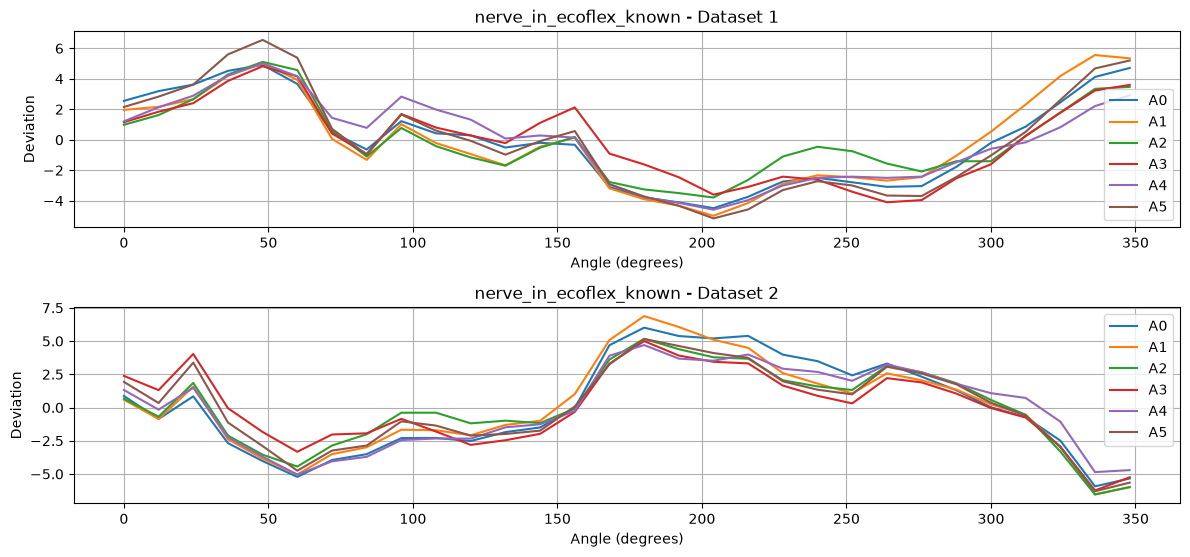

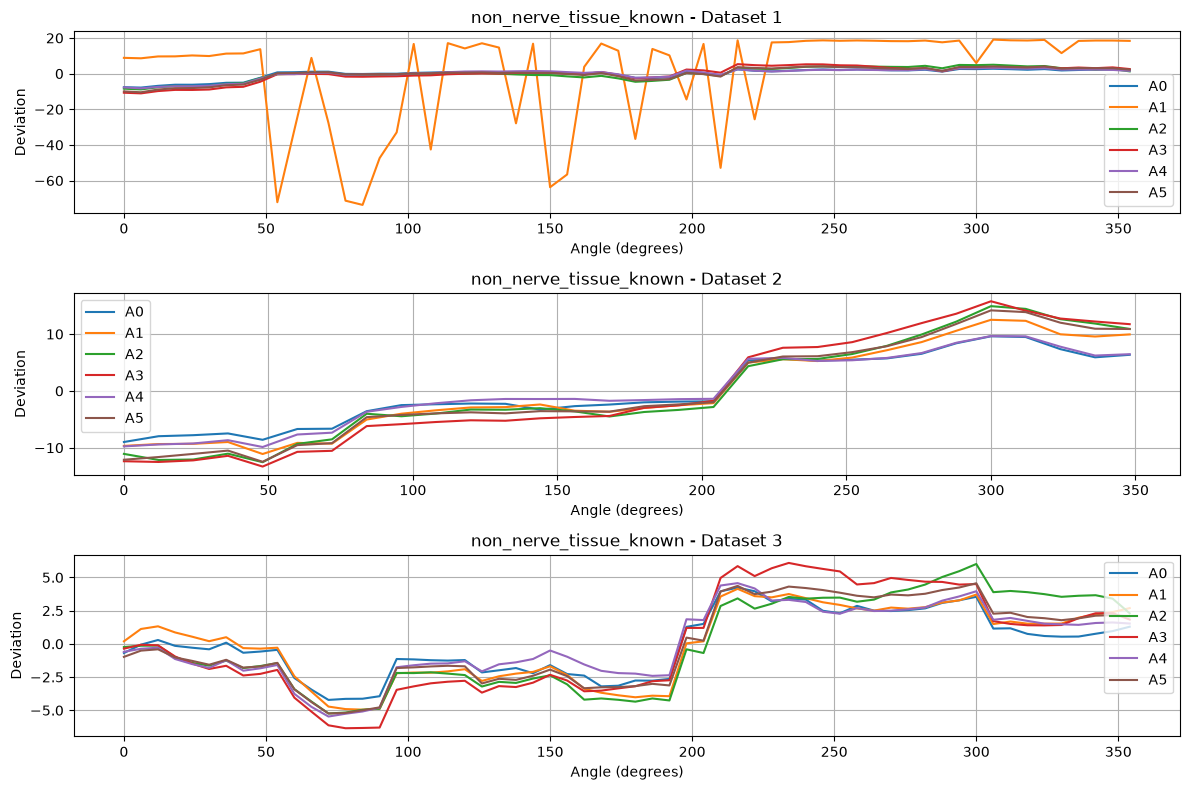

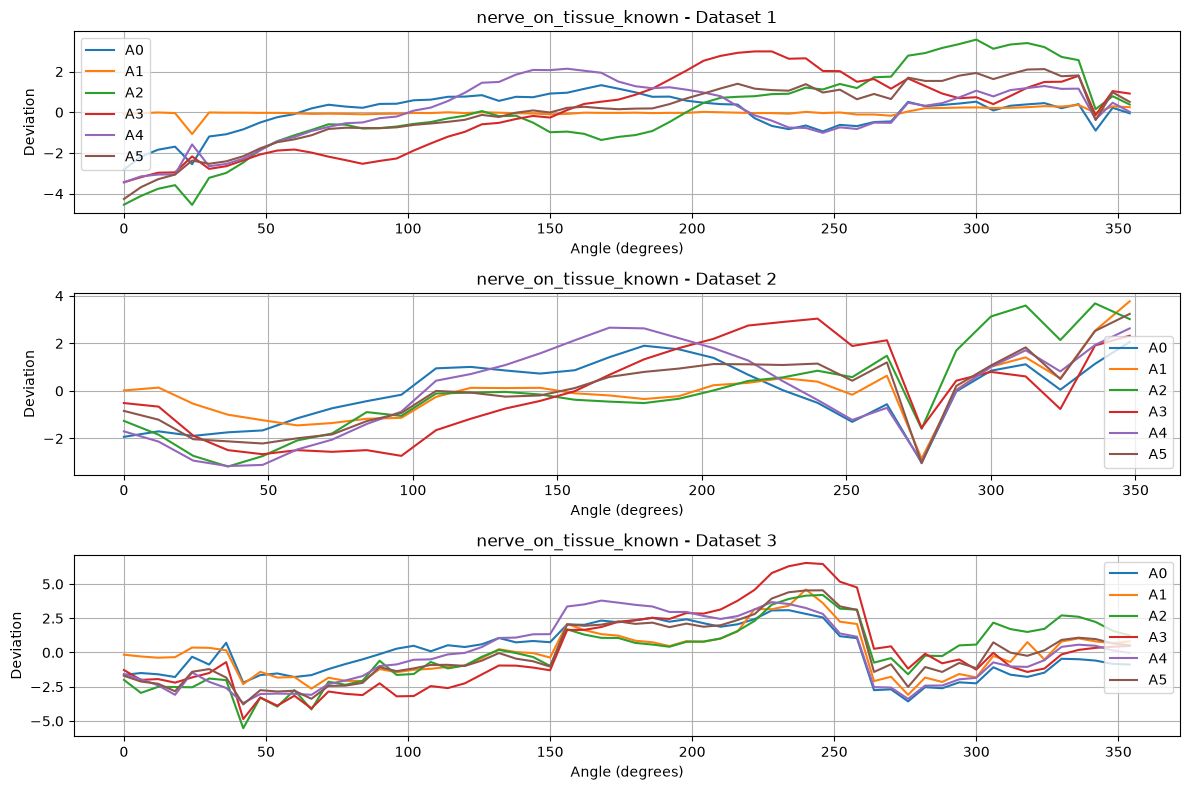

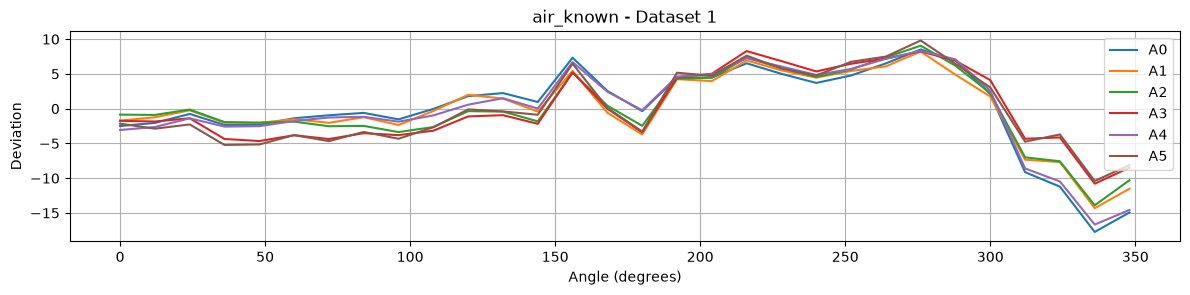

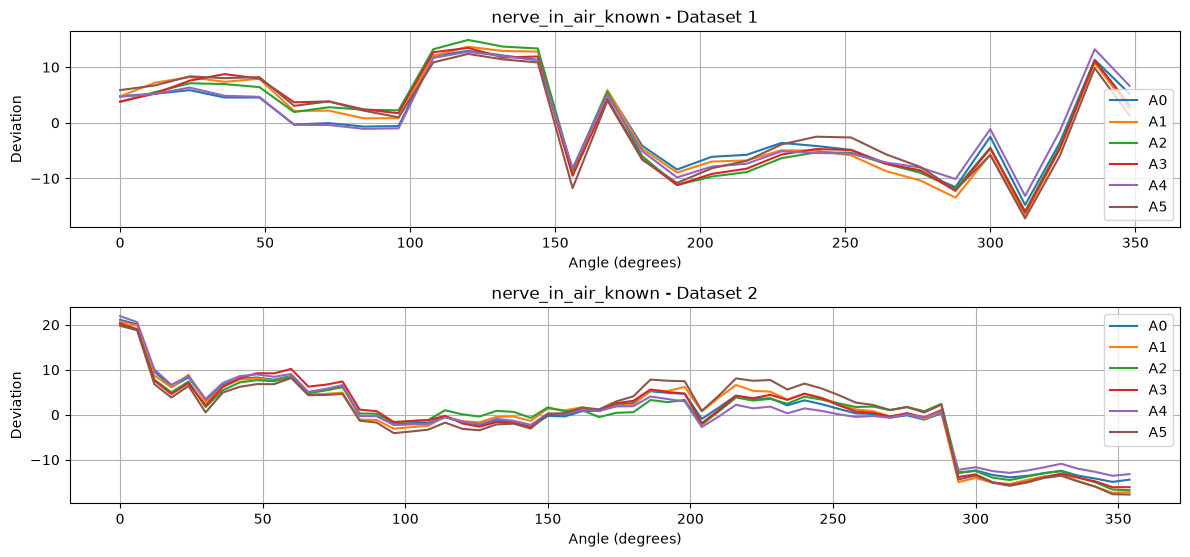

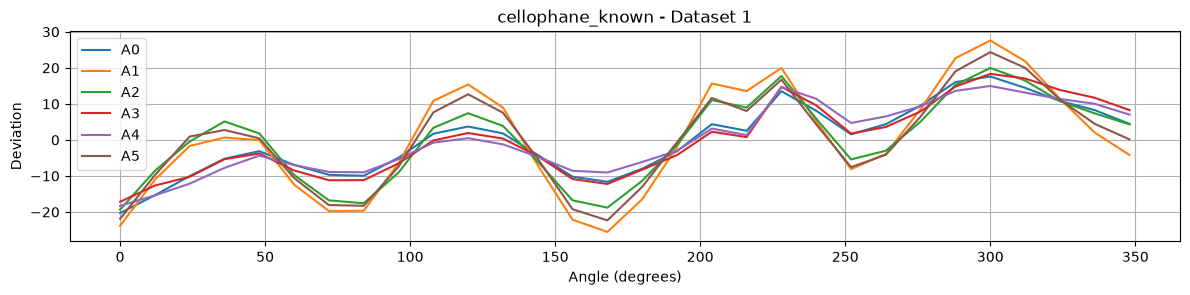

In [262]:
# For each known phantom, plot the A0 to A5 (on the same subplot)
for phantom, datasets in phantoms.items():
    if "known" in phantom and "unknown" not in phantom:
        plt.figure(figsize=(12, 8))
        for i, [df, sample_frequency] in enumerate(datasets):
            plt.subplot(3, 1, i + 1)
            for col in df.columns:
                if col != "angle" and col != "total":
                    plt.plot(df["angle"], df[col], label=col)
            plt.title(f"{phantom} - Dataset {i + 1}")
            plt.xlabel("Angle (degrees)")
            plt.ylabel("Deviation")
            plt.legend()
            plt.grid()
        plt.tight_layout()
        plt.show()

In [263]:
# =============================================================================
# 2. BIREFRINGENCE ANALYSIS & CLASSIFICATION FUNCTION
# =============================================================================
def analyze_birefringence(df, signal_col="total", purity_threshold=0.30):
    """
    Computes spatial FFT, Malus's Law fit, and classifies birefringence.
    Threshold set to 30% k=4 purity to catch single-fold (thin) samples like b_known.
    """
    angles = df["angle"].values
    signal = df[signal_col].values
    N = len(signal)
    
    # --- A. FFT Spectrum Computation ---
    yf = np.fft.fft(signal)
    magnitudes = (2.0 / N) * np.abs(yf[:N // 2])
    
    # Ignore DC offset (index 0)
    power_no_dc = magnitudes[1:] ** 2
    total_ac_power = np.sum(power_no_dc)

    
    
    if total_ac_power > 0:
        dominant_k = np.argmax(power_no_dc) + 1  # Index 0 is k=1
        overall_purity = np.max(power_no_dc) / total_ac_power
        purity_k4 = power_no_dc[3] / total_ac_power if len(power_no_dc) > 3 else 0.0
    else:
        dominant_k, overall_purity, purity_k4 = 0, 0.0, 0.0

    # --- B. Malus's Law (k=4) Curve Fit ---
    def malus_k4(theta_deg, A, phi, C):
        return A * np.cos(4 * np.radians(theta_deg) + phi) + C

    A_guess = (np.max(signal) - np.min(signal)) / 2.0
    C_guess = np.mean(signal)

    try:
        popt, _ = curve_fit(malus_k4, angles, signal, p0=[A_guess, 0.0, C_guess])
        pred = malus_k4(angles, *popt)
        
        ss_res = np.sum((signal - pred) ** 2)
        ss_tot = np.sum((signal - np.mean(signal)) ** 2)
        r2_score = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
        r2_score = max(0.0, r2_score)
    except RuntimeError:
        r2_score = 0.0

    # --- C. Classification Logic ---
    # Birefringent if k=4 is the single dominant spatial harmonic 
    # AND k=4 purity exceeds 30% (distinguishes single-fold from isotropic noise)
    is_birefringent = (dominant_k == 4) and (purity_k4 >= purity_threshold)

    return {
        "Dominant k": int(dominant_k),
        "Overall Purity (%)": round(overall_purity * 100, 2),
        "k=4 Purity (%)": round(purity_k4 * 100, 2),
        "Malus R² Score": round(r2_score, 4),
        "Birefringent": "YES" if is_birefringent else "NO"
    }

In [264]:
# =============================================================================
# 4. RUN BATCH ANALYSIS & DISPLAY SUMMARY TABLE
# =============================================================================
results_list = []

for phantom_name, datasets in phantoms.items():
    for run_idx, [df, sample_freq] in enumerate(datasets):
        metrics = analyze_birefringence(df, signal_col="total", purity_threshold=0.30)
        metrics["Phantom"] = phantom_name
        metrics["Dataset"] = f"Run {run_idx + 1}"
        results_list.append(metrics)

# Format into DataFrame
summary_df = pd.DataFrame(results_list)

# Reorder columns
column_order = [
    "Phantom", "Dataset", "Dominant k", "k=4 Purity (%)", 
    "Overall Purity (%)", "Malus R² Score", "Birefringent"
]
summary_df = summary_df[column_order]

print("\n================ BIREFRINGENCE ANALYSIS RESULTS ================\n")
print(summary_df.to_string(index=False))


================ BIREFRINGENCE ANALYSIS RESULTS ================

               Phantom Dataset  Dominant k  k=4 Purity (%)  Overall Purity (%)  Malus R² Score Birefringent
               a_known   Run 1           1            0.44               29.64          0.0044           NO
               a_known   Run 2           1            2.93               38.00          0.0292           NO
               b_known   Run 1           4           59.80               59.80          0.5977          YES
               b_known   Run 2           4           43.58               43.58          0.4354          YES
               c_known   Run 1           4           78.14               78.14          0.7814          YES
               c_known   Run 2           4           80.69               80.69          0.8064          YES
             d_unknown   Run 1           4           78.87               78.87          0.7883          YES
             d_unknown   Run 2           4           56.26           

C:\Users\orvil\AppData\Local\Temp\ipykernel_19384\1435660641.py:38: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(malus_k4, angles, signal, p0=[A_guess, 0.0, C_guess])


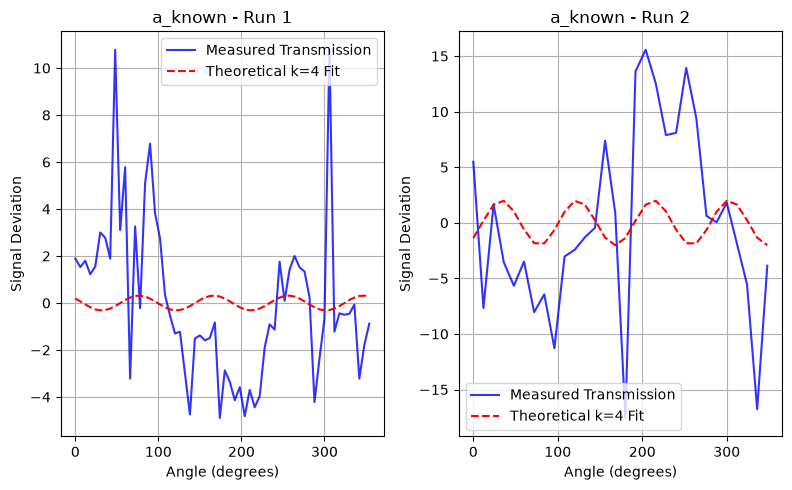

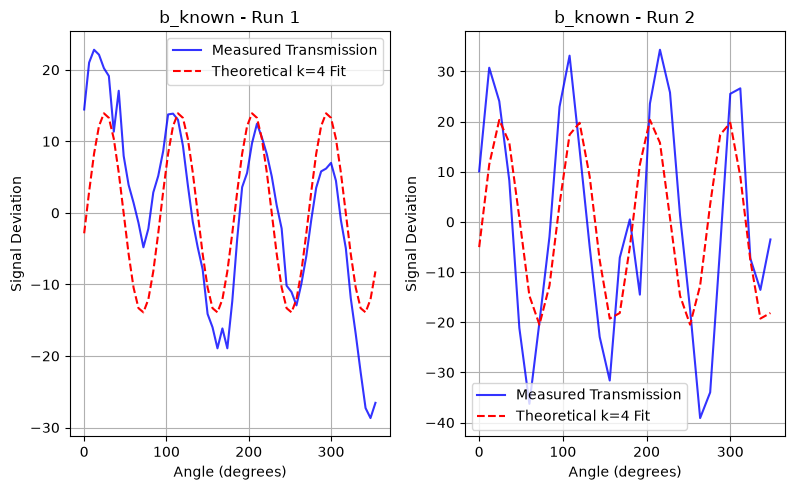

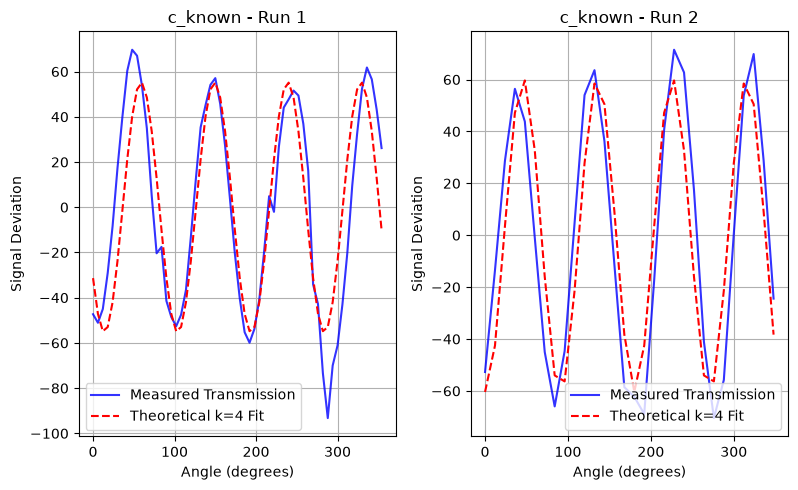

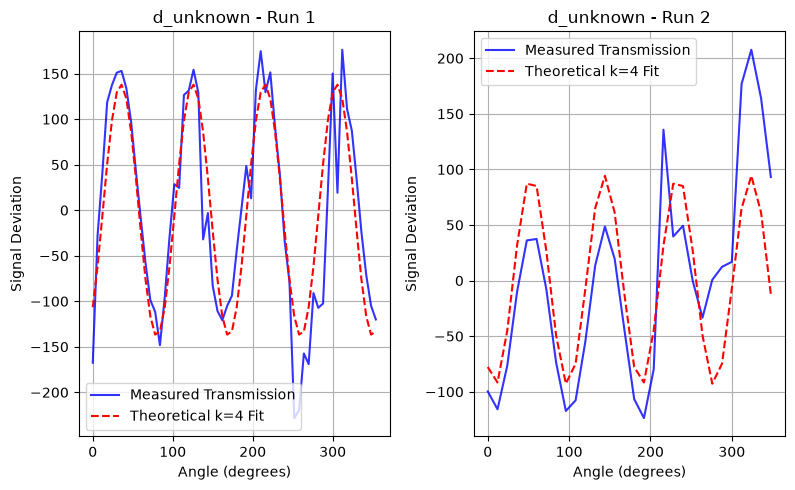

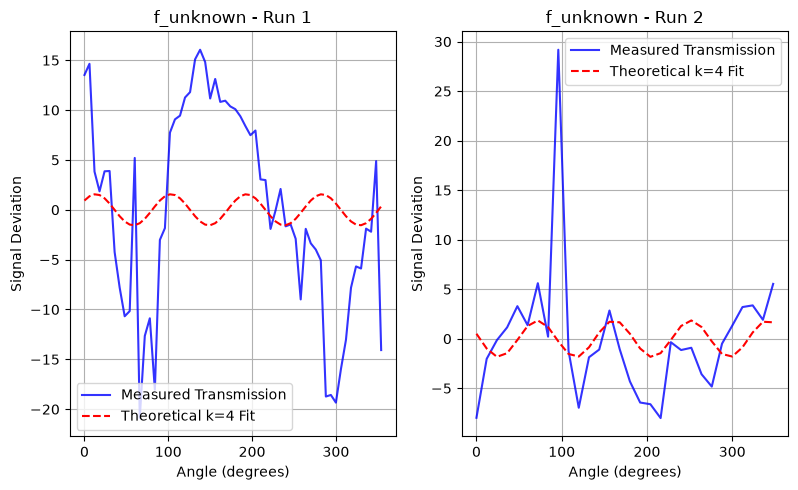

C:\Users\orvil\AppData\Local\Temp\ipykernel_19384\285155469.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(malus_k4, angles, signal, p0=[(max(signal)-min(signal))/2, 0, np.mean(signal)])


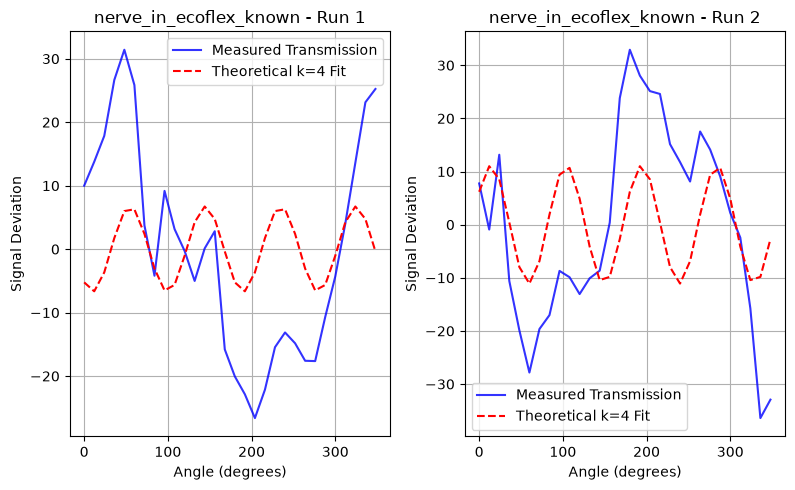

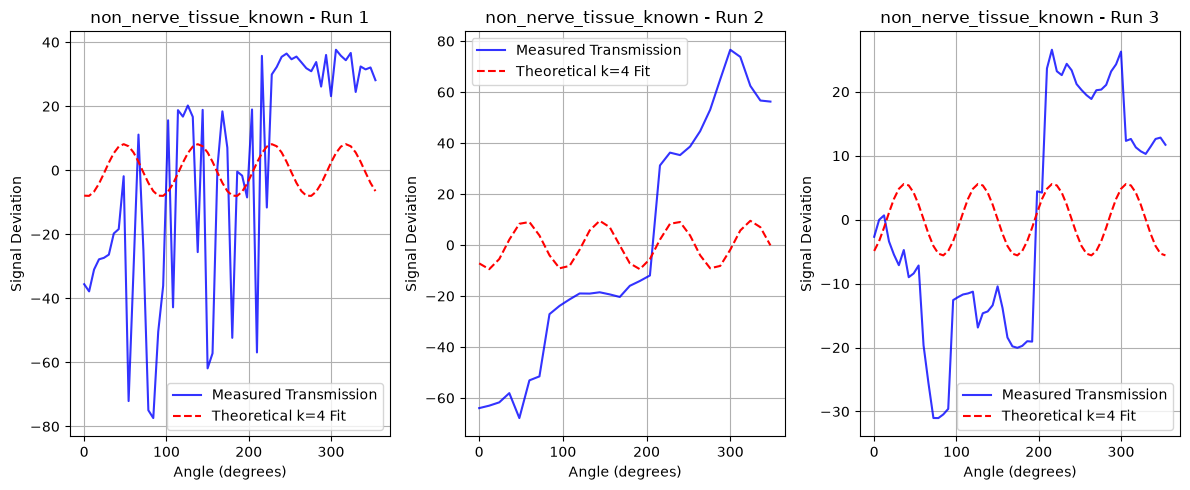

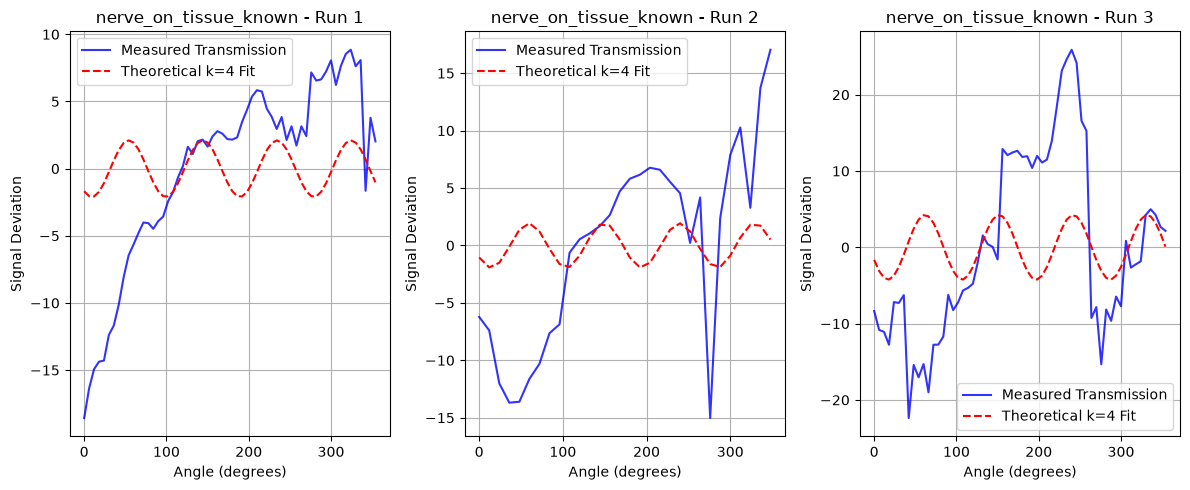

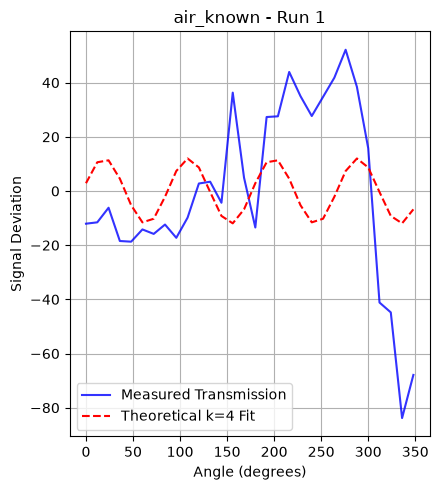

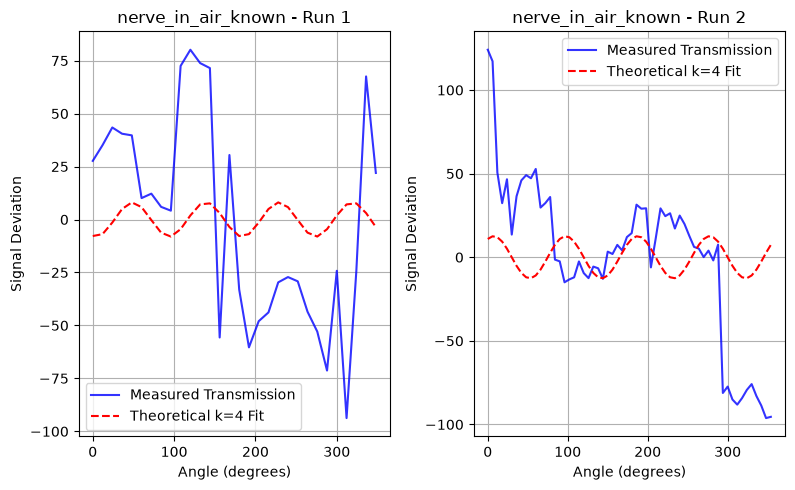

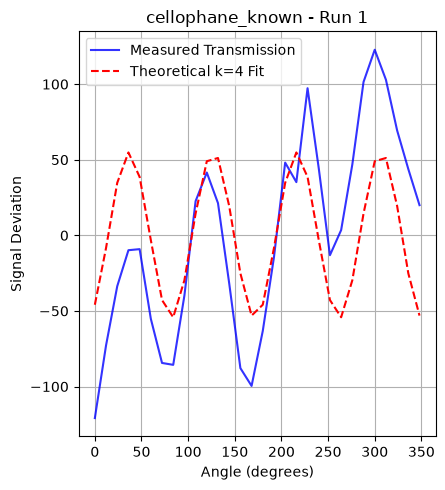

In [265]:
# =============================================================================
# 5. VISUAL OVERLAY PLOTS (RAW SIGNAL VS MALUS K=4 FIT)
# =============================================================================
for phantom_name, datasets in phantoms.items():
    plt.figure(figsize=(12, 5))
    
    for run_idx, [df, sample_freq] in enumerate(datasets):
        angles = df["angle"].values
        signal = df["total"].values
        
        # Fit for visualization
        def malus_k4(theta_deg, A, phi, C):
            return A * np.cos(4 * np.radians(theta_deg) + phi) + C
            
        try:
            popt, _ = curve_fit(malus_k4, angles, signal, p0=[(max(signal)-min(signal))/2, 0, np.mean(signal)])
            fit_line = malus_k4(angles, *popt)
        except RuntimeError:
            fit_line = np.full_like(angles, np.mean(signal))

        plt.subplot(1, 3, run_idx + 1)
        plt.plot(angles, signal, 'b-', label="Measured Transmission", alpha=0.8)
        plt.plot(angles, fit_line, 'r--', label="Theoretical k=4 Fit", lw=1.5)
        plt.title(f"{phantom_name} - Run {run_idx + 1}")
        plt.xlabel("Angle (degrees)")
        plt.ylabel("Signal Deviation")
        plt.legend()
        plt.grid(True)
        
    plt.tight_layout()
    plt.show()

In [266]:
tissue = {
    "tissue_1": [load_dataset(f"data/expt_8_tissue_sample_1.csv"), load_dataset(f"data/expt_8_tissue_sample_1_repeat.csv"), load_dataset(f"data/expt_8_retry_tissue_sample_1.csv"), load_dataset(f"data/expt_8_final_tissue_sample_1.csv")],
    "tissue_2": [load_dataset(f"data/expt_8_tissue_sample_2.csv"), load_dataset(f"data/expt_8_retry_tissue_sample_2.csv"), load_dataset(f"data/expt_8_final_tissue_sample_2.csv")],
}

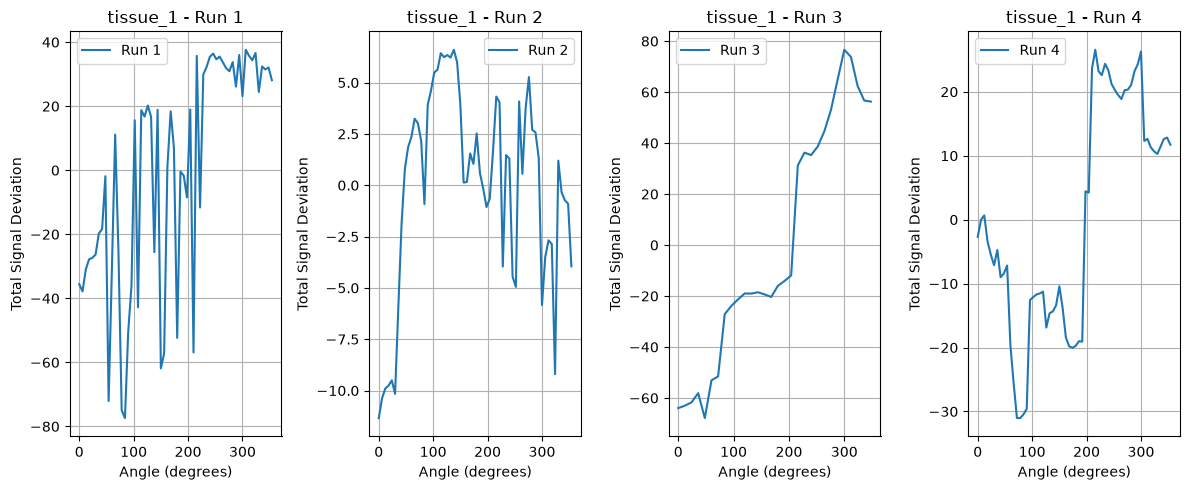

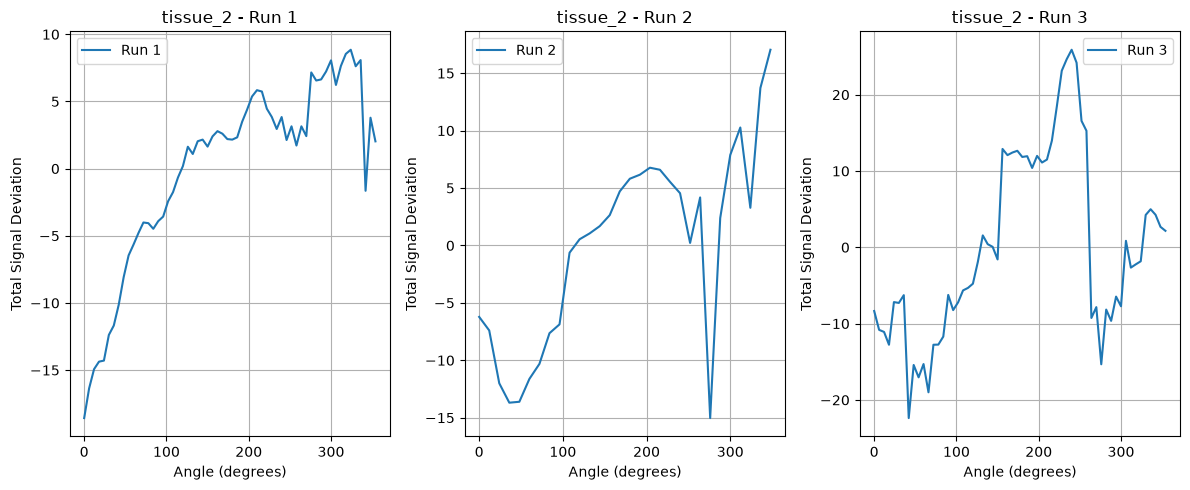

In [267]:
# Plot the total for each tissue sample
for tissue_name, datasets in tissue.items():
    plt.figure(figsize=(12, 5))
    
    for run_idx, [df, sample_freq] in enumerate(datasets):
        plt.subplot(1, len(datasets), run_idx + 1)
        plt.plot(df["angle"], df["total"], label=f"Run {run_idx + 1}")
        plt.title(f"{tissue_name} - Run {run_idx + 1}")
        plt.xlabel("Angle (degrees)")
        plt.ylabel("Total Signal Deviation")
        plt.legend()
        plt.grid(True)
        
    plt.tight_layout()
    plt.show()

In [268]:
# =============================================================================
# 4. RUN BATCH ANALYSIS & DISPLAY SUMMARY TABLE
# =============================================================================
results_list = []

for tissue_name, datasets in tissue.items():
    for run_idx, [df, sample_freq] in enumerate(datasets):
        metrics = analyze_birefringence(df, signal_col="total", purity_threshold=0.30)
        metrics["Tissue"] = tissue_name
        metrics["Dataset"] = f"Run {run_idx + 1}"
        results_list.append(metrics)

# Format into DataFrame
summary_df = pd.DataFrame(results_list)

# Reorder columns
column_order = [
    "Tissue", "Dataset", "Dominant k", "k=4 Purity (%)", 
    "Overall Purity (%)", "Malus R² Score", "Birefringent"
]
summary_df = summary_df[column_order]

print("\n================ BIREFRINGENCE ANALYSIS RESULTS ================\n")
print(summary_df.to_string(index=False))


================ BIREFRINGENCE ANALYSIS RESULTS ================

  Tissue Dataset  Dominant k  k=4 Purity (%)  Overall Purity (%)  Malus R² Score Birefringent
tissue_1   Run 1           1            2.76               41.56          0.0276           NO
tissue_1   Run 2           1            1.09               36.93          0.0108           NO
tissue_1   Run 3           1            2.10               65.42          0.0210           NO
tissue_1   Run 4           1            5.06               80.27          0.0506           NO
tissue_2   Run 1           1            4.74               51.39          0.0474           NO
tissue_2   Run 2           1            2.67               32.92          0.0267           NO
tissue_2   Run 3           1            6.32               59.60          0.0632           NO


In [269]:
def plot_fft(df, signal_col="total", title=None, max_k=12, highlight_k=4):
    """
    Computes and plots the FFT magnitude spectrum in terms of Harmonic Order (k).
    
    Parameters:
        df: DataFrame containing 'angle' (0-360 deg) and the target signal.
        signal_col: Name of column to compute FFT on (default "total").
        title: Custom plot title.
        max_k: Highest harmonic order k to show on the x-axis (default 12).
        highlight_k: Harmonic order to visually emphasize (default 4 for birefringence).
    """
    signal = df[signal_col].values
    N = len(signal)
    
    # Compute 1D Real FFT
    yf = np.fft.fft(signal)
    magnitudes = (2.0 / N) * np.abs(yf[:N // 2])
    
    # Spatial harmonic order k (0, 1, 2, 3... cycles per 360 degrees)
    harmonic_orders = np.arange(N // 2)
    
    # Filter up to max_k, excluding DC component (k=0) for proper y-axis scaling
    k_axis = harmonic_orders[1 : max_k + 1]
    mag_axis = magnitudes[1 : max_k + 1]
    
    plt.figure(figsize=(9, 4.5))
    
    # Stem plot for discrete spatial frequencies
    markerline, stemlines, baseline = plt.stem(
        k_axis, mag_axis, linefmt="b-", markerfmt="bo", basefmt="k-"
    )
    plt.setp(markerline, markersize=6)
    
    # Highlight specific harmonic peak (e.g., k=4 for birefringence)
    if highlight_k in k_axis:
        k_idx = highlight_k - 1  # 0-indexed offset since k starts at 1
        plt.stem(
            [highlight_k], [mag_axis[k_idx]], 
            linefmt="r-", markerfmt="ro", basefmt="k-", 
            label=f"Target $k={highlight_k}$ Peak"
        )
        plt.legend(loc="upper right")

    plt.xlabel("Harmonic Order $k$ (cycles / 360°)", fontsize=11)
    plt.ylabel("Magnitude", fontsize=11)
    plt.title(title if title else f"FFT Spectrum - '{signal_col}'", fontsize=12)
    plt.xticks(np.arange(1, max_k + 1))
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

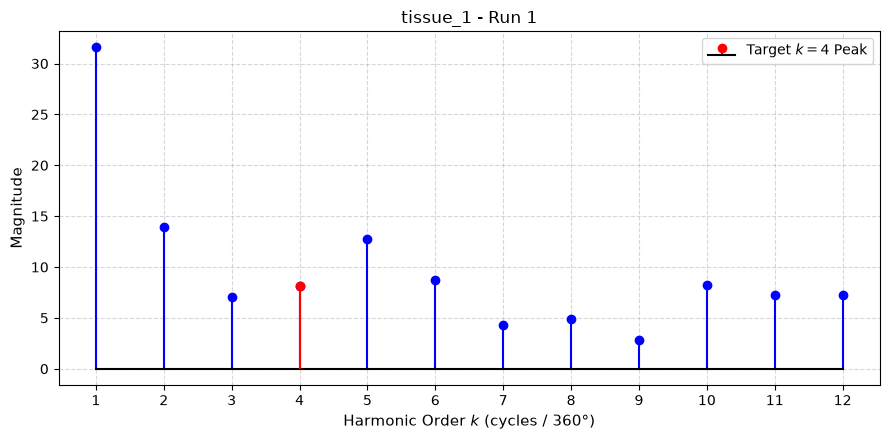

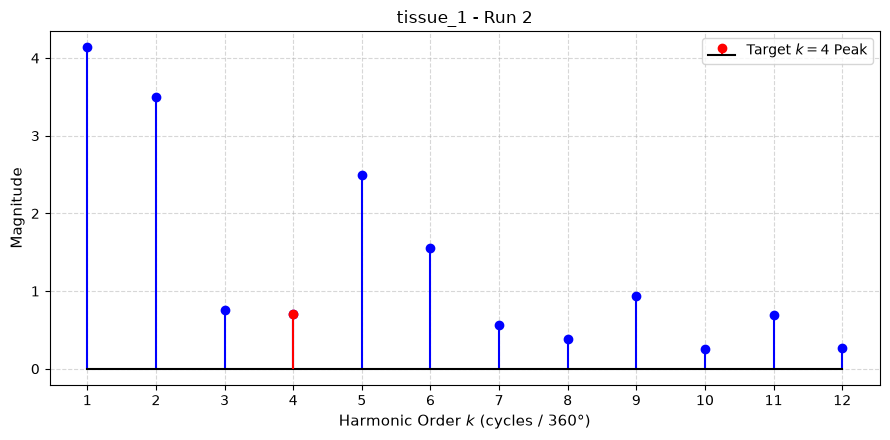

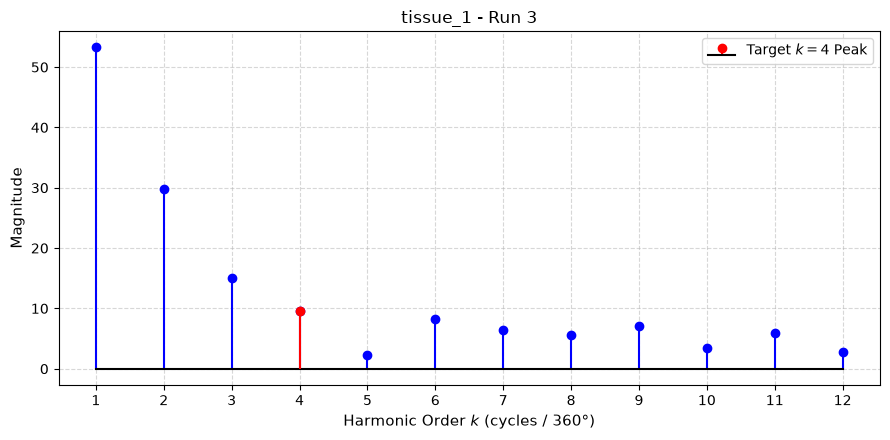

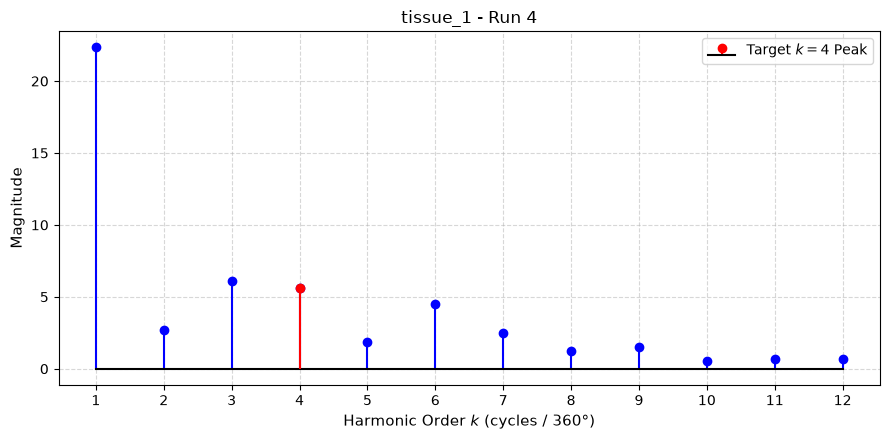

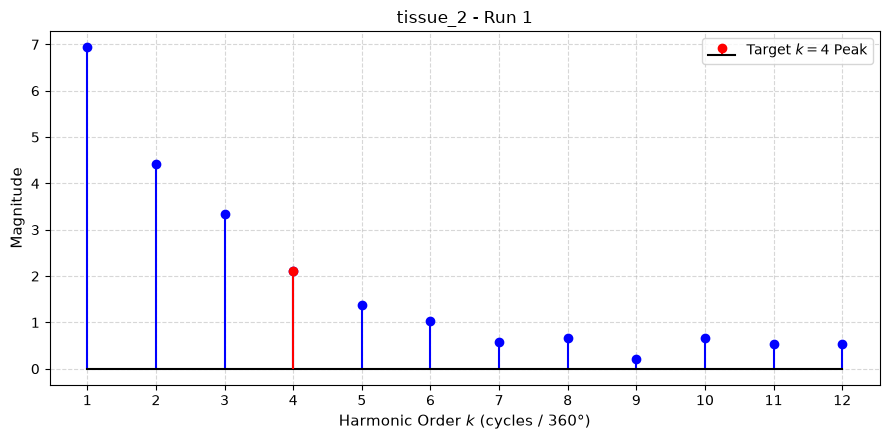

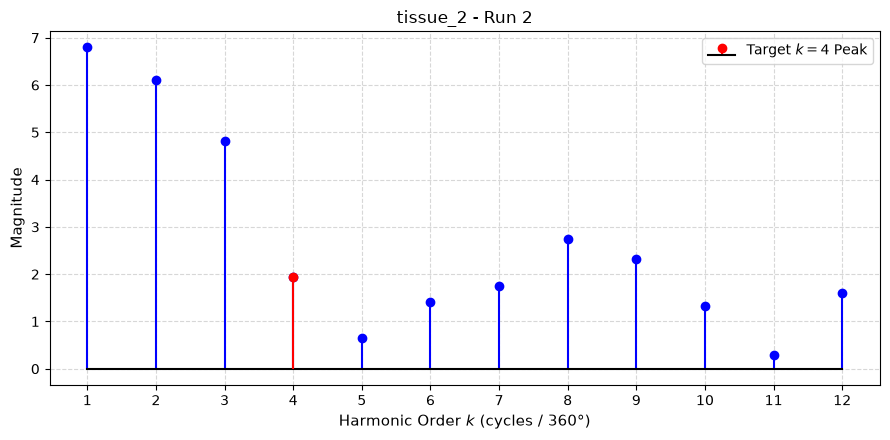

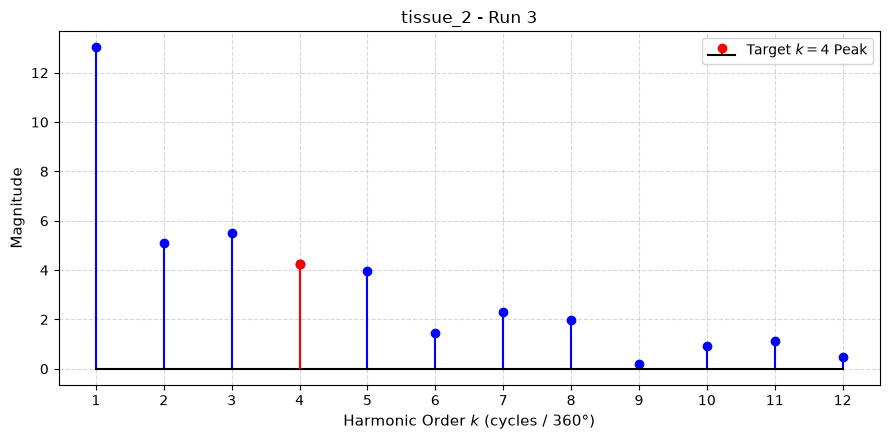

In [270]:
for tissue_name, datasets in tissue.items():
    for run_idx, [df, sample_freq] in enumerate(datasets):
        plot_fft(df, signal_col="total", title=f"{tissue_name} - Run {run_idx + 1}", max_k=12, highlight_k=4)

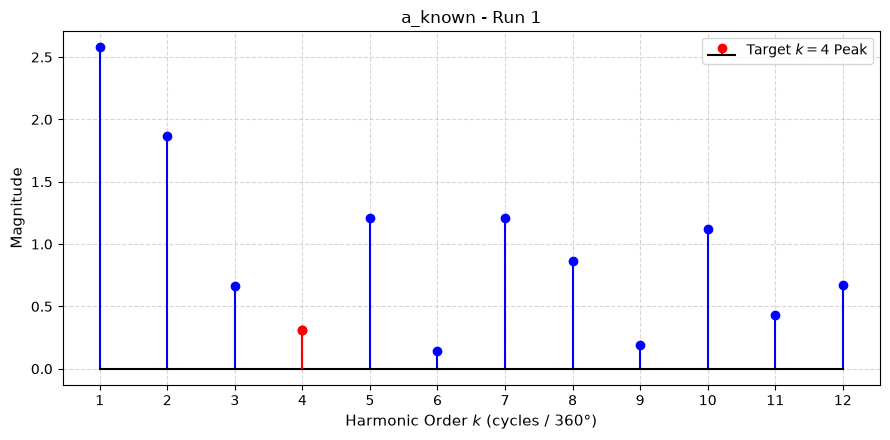

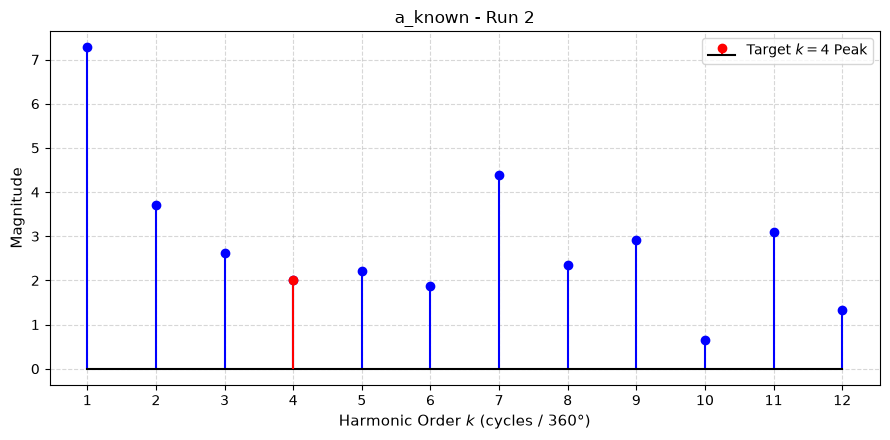

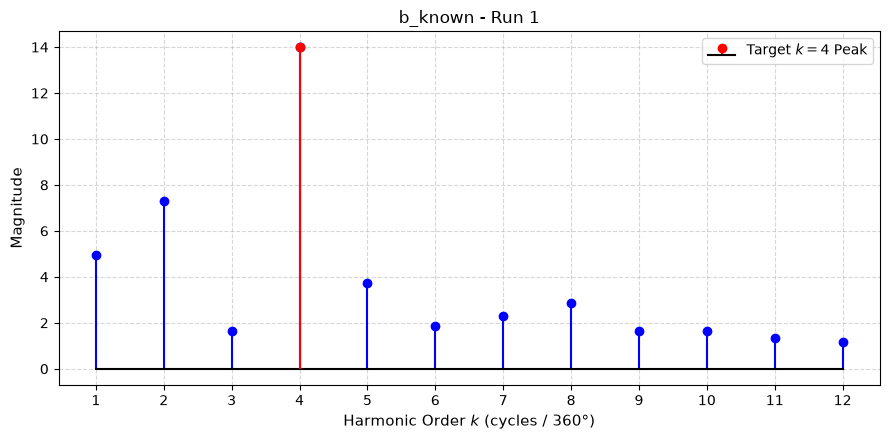

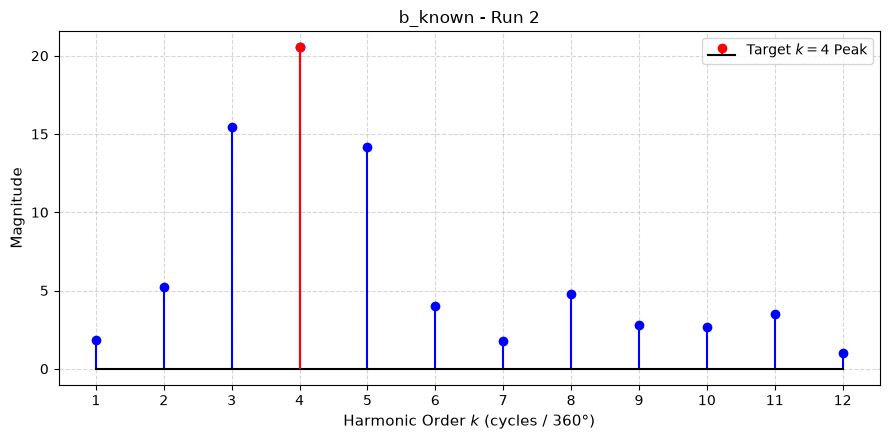

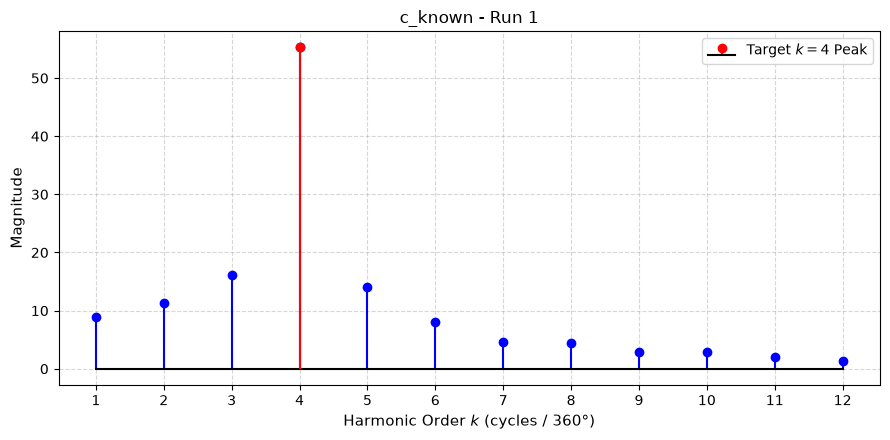

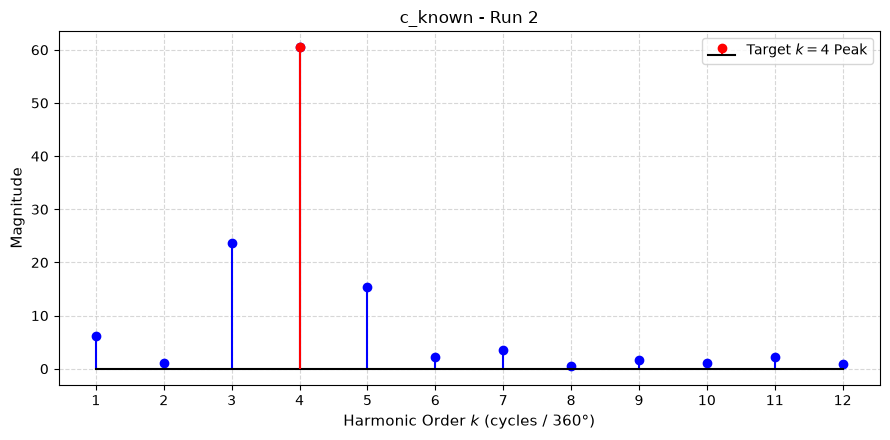

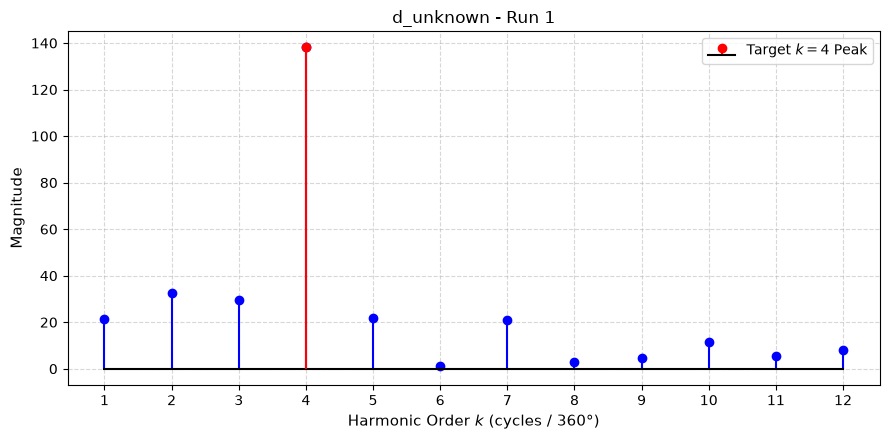

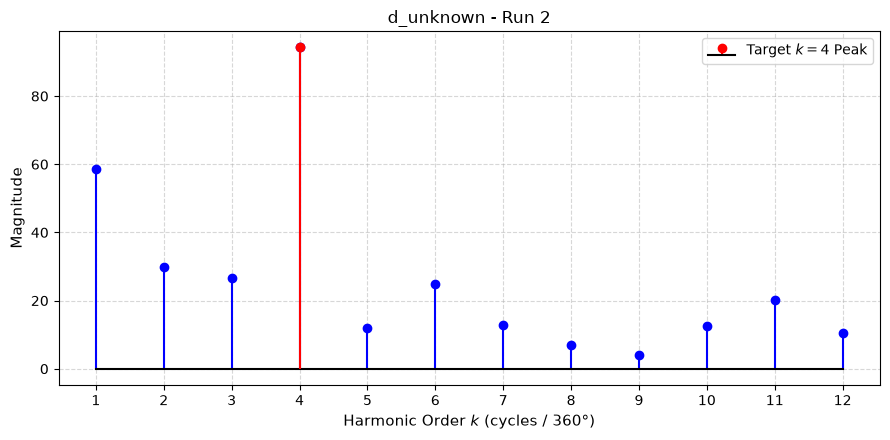

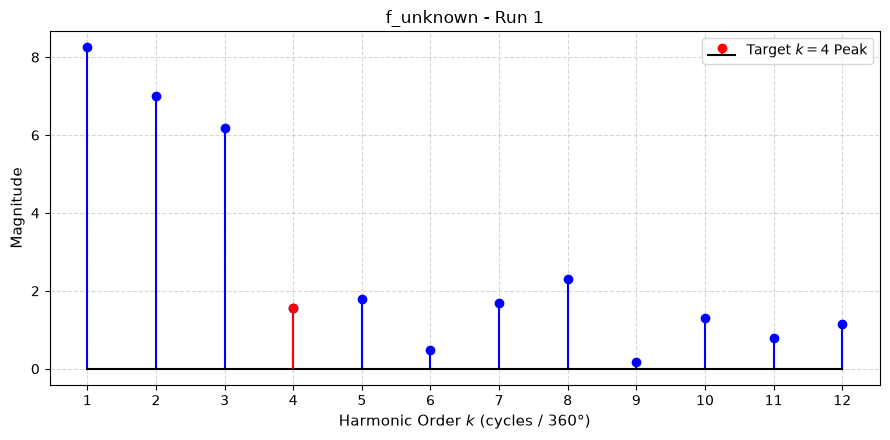

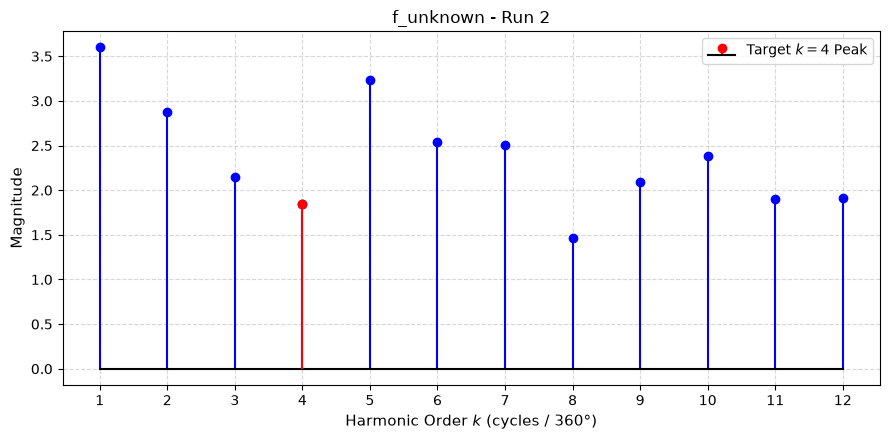

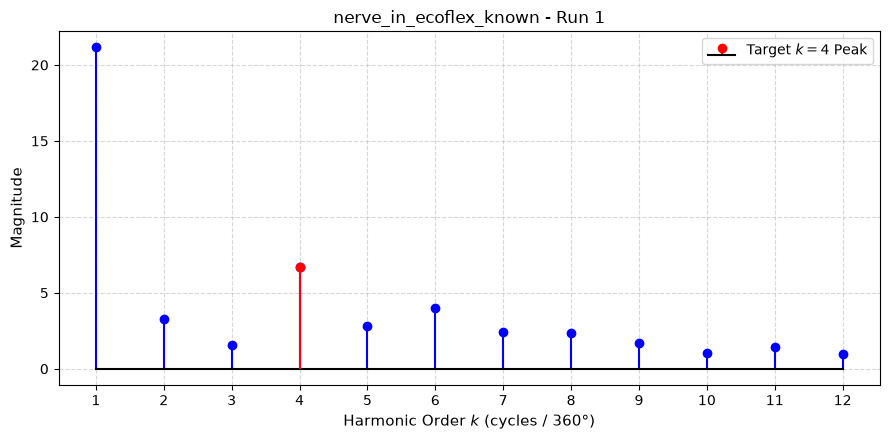

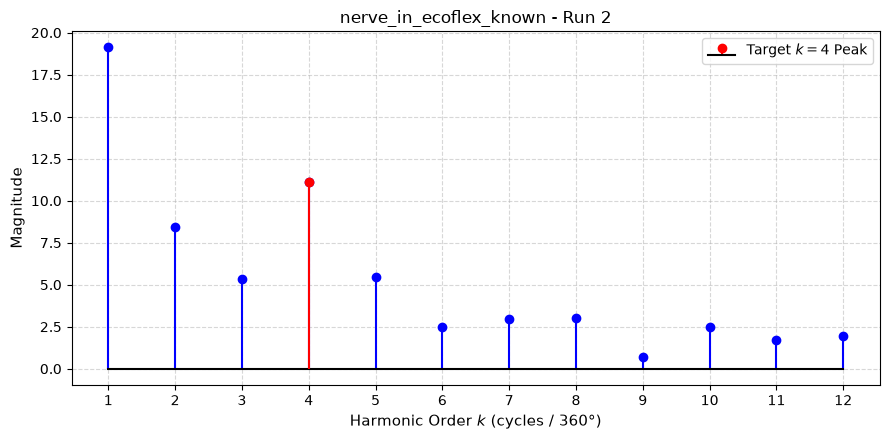

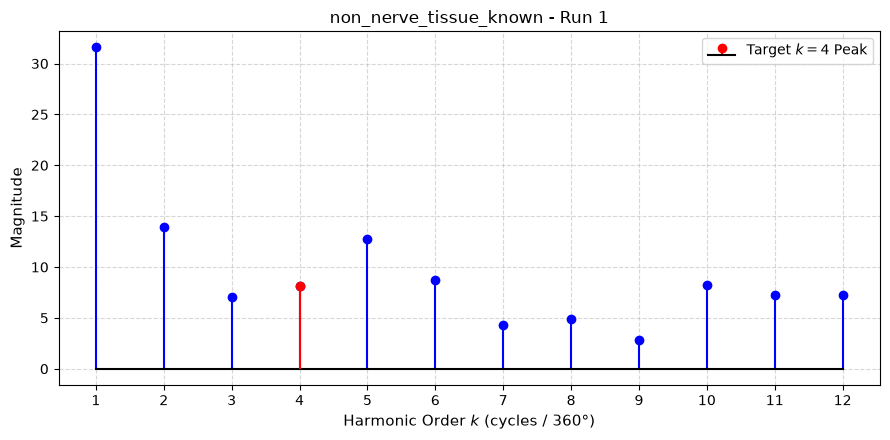

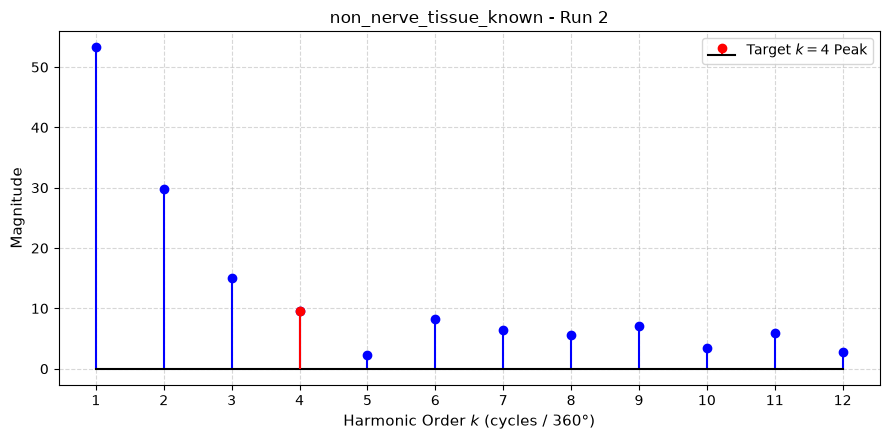

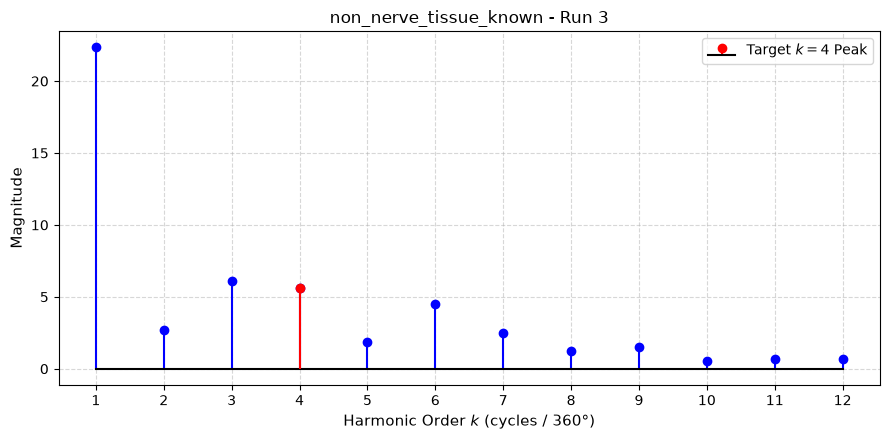

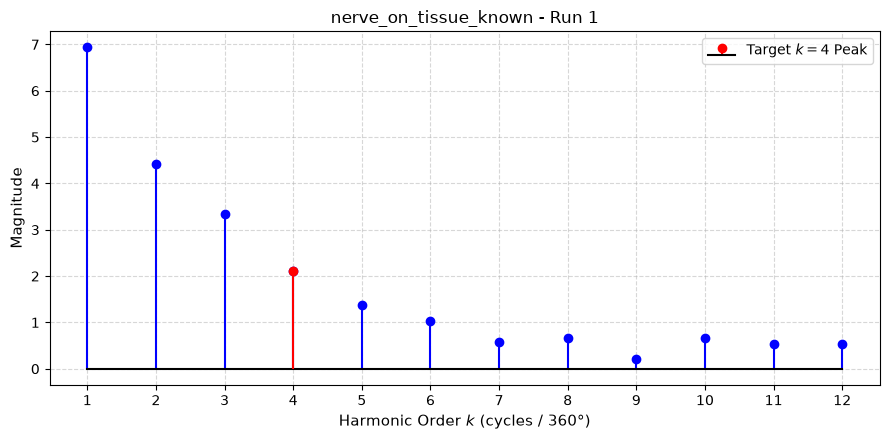

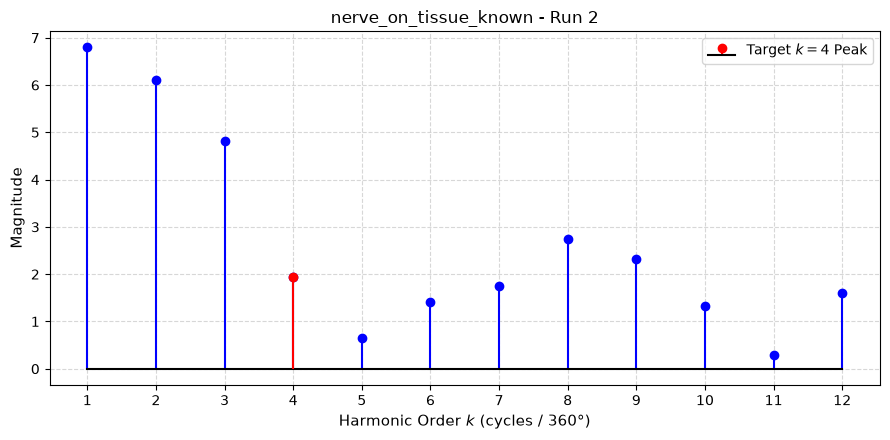

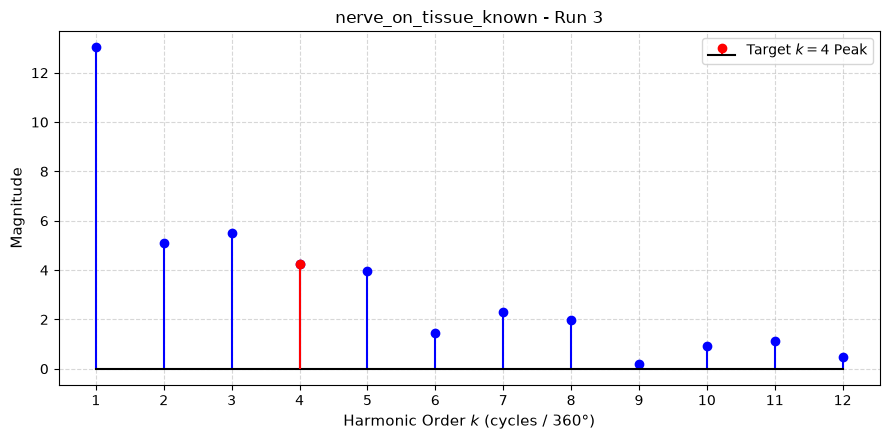

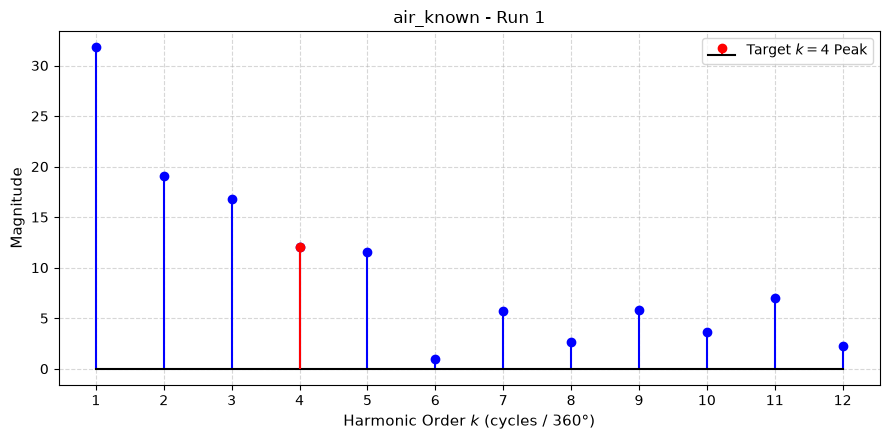

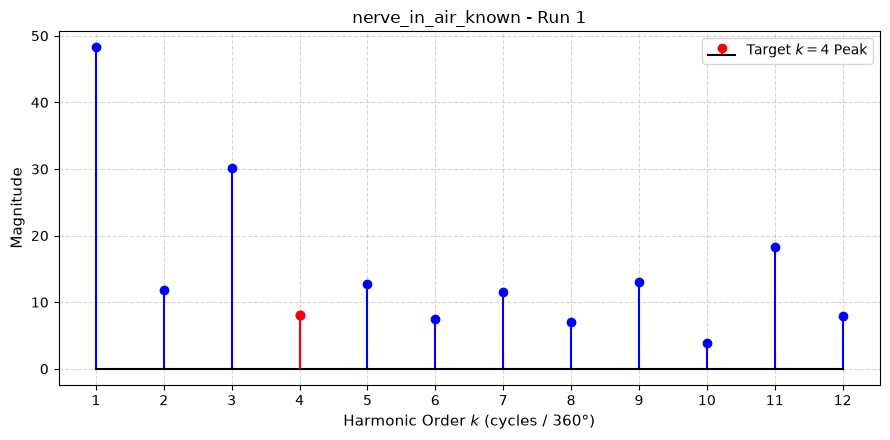

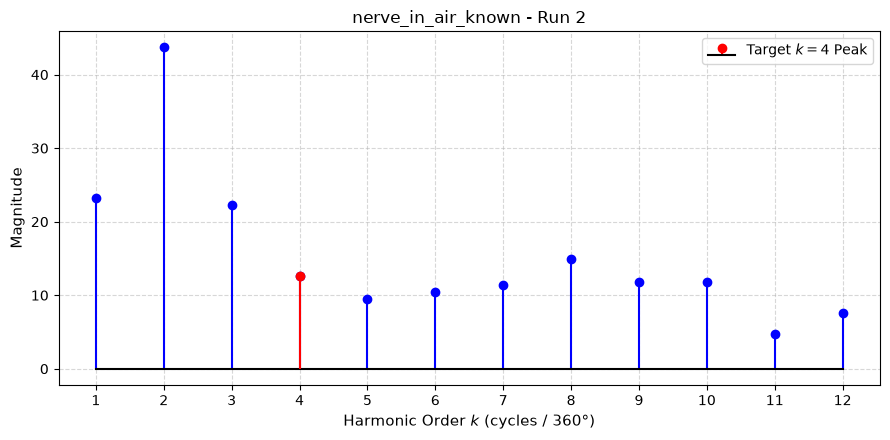

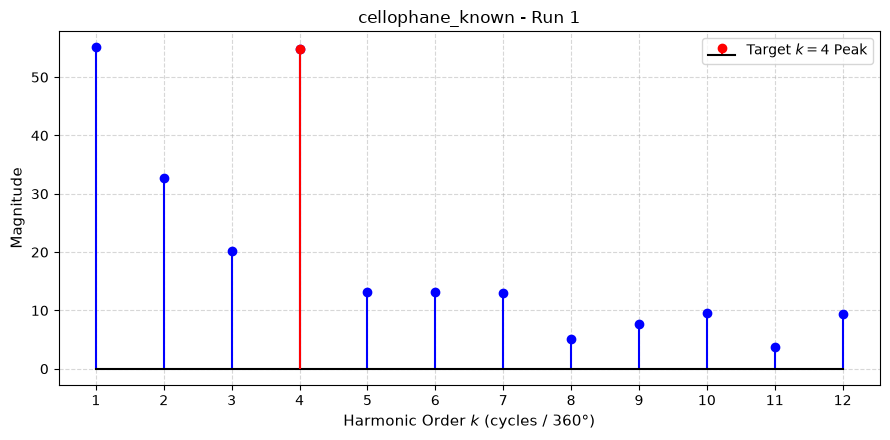

In [271]:
for tissue_name, datasets in phantoms.items():
    for run_idx, [df, sample_freq] in enumerate(datasets):
        plot_fft(df, signal_col="total", title=f"{tissue_name} - Run {run_idx + 1}", max_k=12, highlight_k=4)